## Clustering

Clustering is the process of grouping objects from a dataset such that objects in the same group (called a cluster) are more similar (in some sense) to each other than to those in other groups ([Wikipedia](https://en.wikipedia.org/wiki/Cluster_analysis)). Scikit-learn offers several clustering algorithms. You can learn more about them here: https://scikit-learn.org/stable/modules/clustering.html

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
%matplotlib inline

In [3]:
iris_df = sns.load_dataset('iris')

In [ ]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
iris_df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

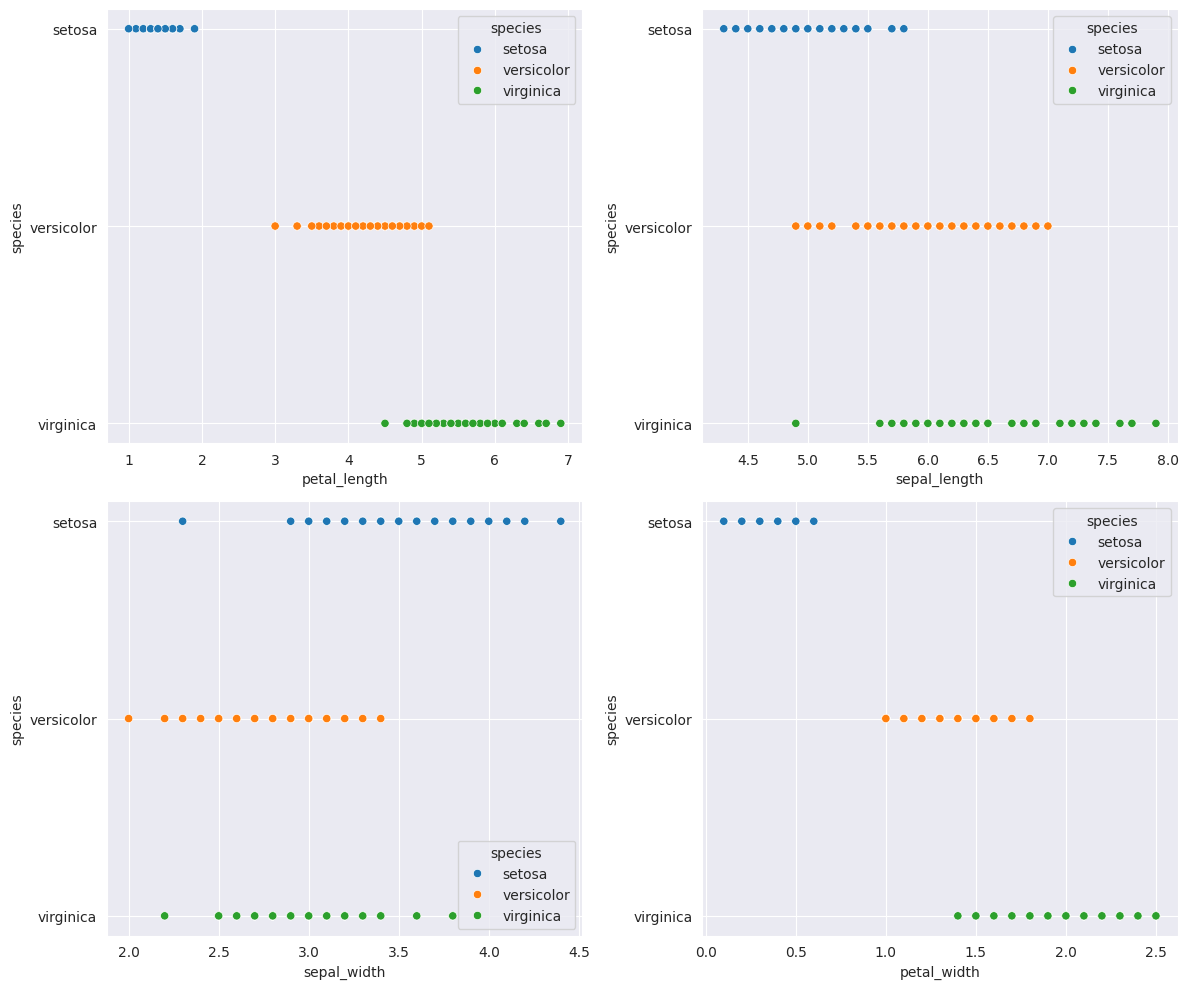

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data=iris_df, y='species', x='petal_length', hue='species', ax=axes[0, 0])
sns.scatterplot(data=iris_df, y='species', x='sepal_length', hue='species', ax=axes[0, 1])
sns.scatterplot(data=iris_df, y='species', x='sepal_width', hue='species', ax=axes[1, 0])
sns.scatterplot(data=iris_df, y='species', x='petal_width', hue='species', ax=axes[1, 1])
plt.tight_layout()
plt.show()

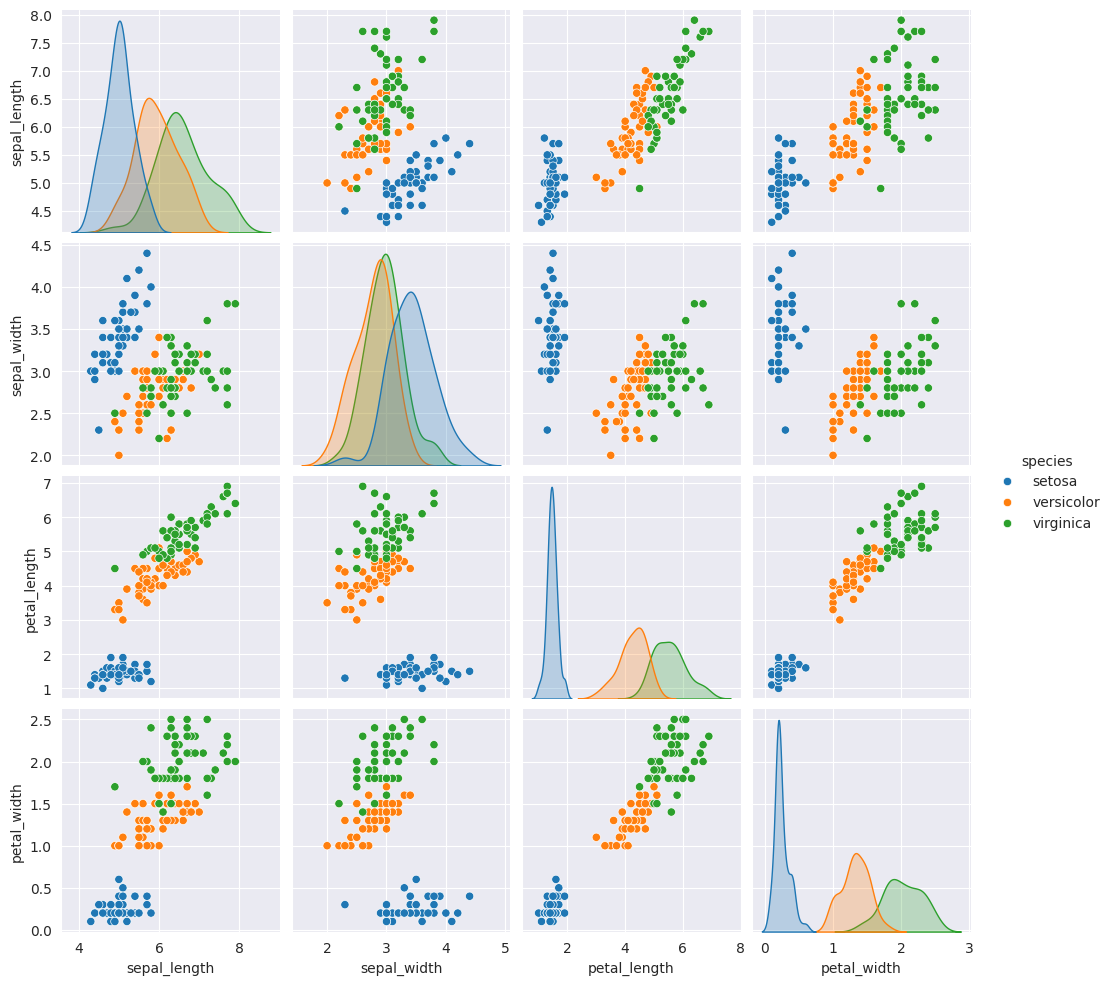

In [ ]:
sns.pairplot(iris_df, hue='species')

In [ ]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
num_cols=['petal_length', 'petal_width', 'sepal_length', 'sepal_width']

In [ ]:
X=iris_df[num_cols]

In [ ]:
X

,petal_length,petal_width,sepal_length,sepal_width
0,1.4,0.2,5.1,3.5
1,1.4,0.2,4.9,3.0
2,1.3,0.2,4.7,3.2
3,1.5,0.2,4.6,3.1
4,1.4,0.2,5.0,3.6
...,...,...,...,...
145,5.2,2.3,6.7,3.0
146,5.0,1.9,6.3,2.5
147,5.2,2.0,6.5,3.0
148,5.4,2.3,6.2,3.4


### K Means Clustering

The K-means algorithm attempts to classify objects into a pre-determined number of clusters by finding optimal central points (called centroids) for each cluster. Each object is classifed as belonging the cluster represented by the closest centroid.

<img src="https://miro.medium.com/max/1400/1*rw8IUza1dbffBhiA4i0GNQ.png" width="640">

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
model = KMeans(n_clusters=3, random_state=42)

In [ ]:
model.fit(X)

KMeans(n_clusters=3, random_state=42)

In [ ]:
model.cluster_centers_

array([[5.71538462, 2.05384615, 6.85384615, 3.07692308],
       [1.462     , 0.246     , 5.006     , 3.428     ],
       [4.38852459, 1.43442623, 5.88360656, 2.74098361]])

In [ ]:
preds = model.predict(X)
preds

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

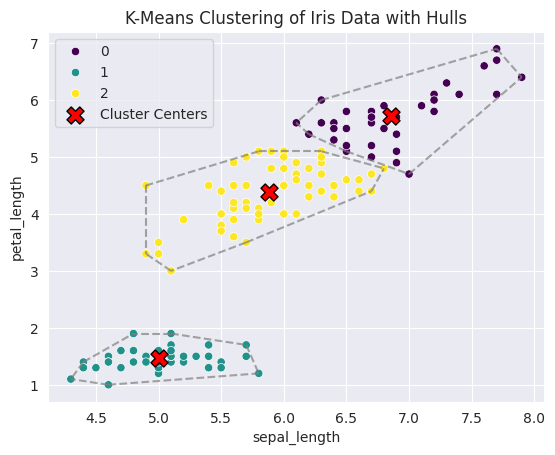

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull
import numpy as np

# Plot the data points colored by their assigned clusters
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds, palette='viridis', legend='full')

# Extract coordinates for cluster centers based on the plotted features
# 'sepal_length' corresponds to index 2 in num_cols
# 'petal_length' corresponds to index 0 in num_cols
centers_x = model.cluster_centers_[:, num_cols.index('sepal_length')]
centers_y = model.cluster_centers_[:, num_cols.index('petal_length')]

# Plot the cluster centers
# s=150 sets the size of the marker
plt.scatter(centers_x, centers_y, marker='X', s=150, color='red', edgecolor='black', label='Cluster Centers')

# Add convex hulls around each cluster
for i in np.unique(preds):
    points_in_cluster = X[preds == i][['sepal_length', 'petal_length']].values
    if len(points_in_cluster) > 2: # ConvexHull requires at least 3 points
        hull = ConvexHull(points_in_cluster)
        for simplex in hull.simplices:
            plt.plot(points_in_cluster[simplex, 0], points_in_cluster[simplex, 1], linestyle='--', color='gray', alpha=0.7)


plt.title('K-Means Clustering of Iris Data with Hulls')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.show()

We can check the "goodness" of the fit by looking at `model.inertia_`, which contains the sum of squared distances of samples to their closest cluster center. Lower the inertia, better the fit.

In [ ]:
model.inertia_

78.85566582597727

Let's try creating 6 clusters.

In [ ]:
model=KMeans(n_clusters=6,random_state=42)
model.fit(X)
preds=model.predict(X)

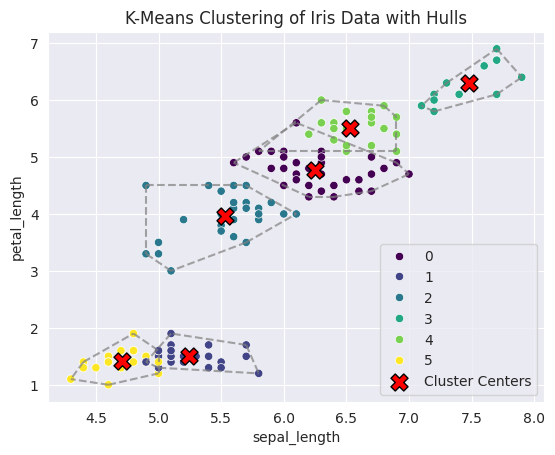

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull
import numpy as np

# Plot the data points colored by their assigned clusters
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds, palette='viridis', legend='full')

# Extract coordinates for cluster centers based on the plotted features
# 'sepal_length' corresponds to index 2 in num_cols
# 'petal_length' corresponds to index 0 in num_cols
centers_x = model.cluster_centers_[:, num_cols.index('sepal_length')]
centers_y = model.cluster_centers_[:, num_cols.index('petal_length')]

# Plot the cluster centers
# s=150 sets the size of the marker
plt.scatter(centers_x, centers_y, marker='X', s=150, color='red', edgecolor='black', label='Cluster Centers')

# Add convex hulls around each cluster
for i in np.unique(preds):
    points_in_cluster = X[preds == i][['sepal_length', 'petal_length']].values
    if len(points_in_cluster) > 2: # ConvexHull requires at least 3 points
        hull = ConvexHull(points_in_cluster)
        for simplex in hull.simplices:
            plt.plot(points_in_cluster[simplex, 0], points_in_cluster[simplex, 1], linestyle='--', color='gray', alpha=0.7)


plt.title('K-Means Clustering of Iris Data with Hulls')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.show()

In most real-world scenarios, there's no predetermined number of clusters. In such a case, you can create a plot of "No. of clusters" vs "Inertia" to pick the right number of clusters.

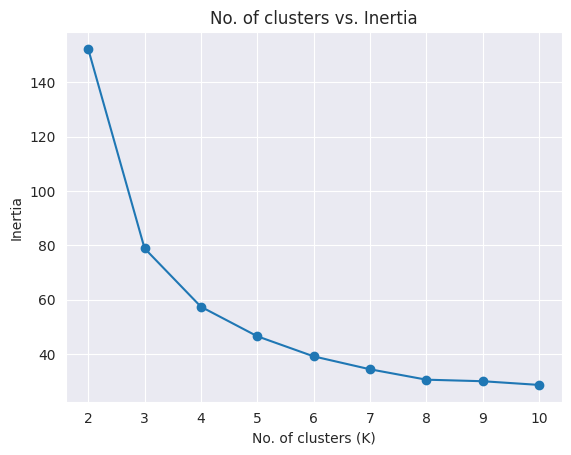

In [ ]:
options = range(2,11)
inertias = []

for n_clusters in options:
    model = KMeans(n_clusters, random_state=42).fit(X)
    inertias.append(model.inertia_)

plt.title("No. of clusters vs. Inertia")
plt.plot(options, inertias, '-o')
plt.xlabel('No. of clusters (K)')
plt.ylabel('Inertia');

The chart is creates an "elbow" plot, and you can pick the number of clusters beyond which the reduction in inertia decreases sharply.

---

**Mini Batch K Means**: The K-means algorithm can be quite slow for really large dataset. Mini-batch K-means is an iterative alternative to K-means that works well for large datasets. Learn more about it here: https://scikit-learn.org/stable/modules/clustering.html#mini-batch-kmeans


> **EXERCISE**: Perform clustering on the [Mall customers dataset](https://www.kaggle.com/vjchoudhary7/customer-segmentation-tutorial-in-python) on Kaggle. Study the segments carefully and report your observations.

In [ ]:
mall_df=pd.read_csv('/content/Mall_Customers.csv')

In [ ]:
mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
mall_df.info()
mall_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


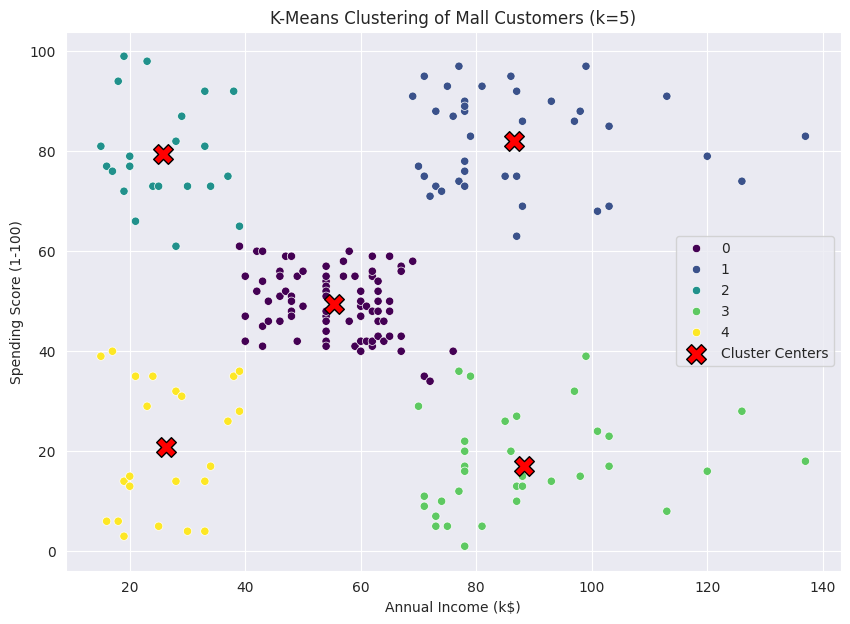

In [ ]:
X_mall = mall_df[['Annual Income (k$)', 'Spending Score (1-100)']]

model_mall = KMeans(n_clusters=5, random_state=42)
model_mall.fit(X_mall)
preds_mall = model_mall.predict(X_mall)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=X_mall, x='Annual Income (k$)', y='Spending Score (1-100)', hue=preds_mall, palette='viridis', legend='full')

centers_x_mall = model_mall.cluster_centers_[:, 0]
centers_y_mall = model_mall.cluster_centers_[:, 1]
plt.scatter(centers_x_mall, centers_y_mall, marker='X', s=200, color='red', edgecolor='black', label='Cluster Centers')

plt.title('K-Means Clustering of Mall Customers (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

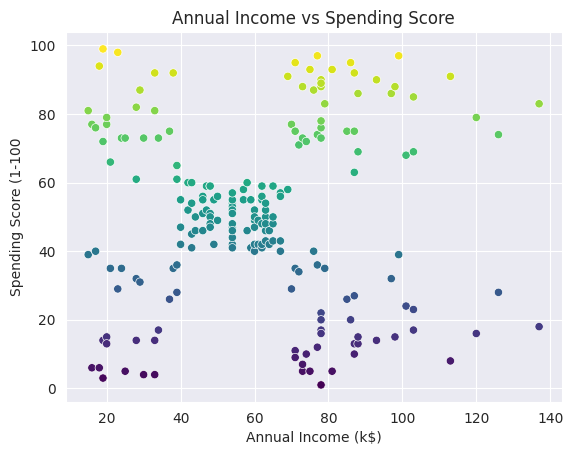

In [ ]:
X_mall = mall_df[['Annual Income (k$)', 'Spending Score (1-100)']]

sns.scatterplot(data=X_mall, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending Score (1-100)', palette='viridis', legend=False)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100')
plt.title('Annual Income vs Spending Score')
plt.show()

------------

# DBSCAN

### DBSCAN

Density-based spatial clustering of applications with noise (DBSCAN) uses the density of points in a region to form clusters. It has two main parameters: "epsilon" and "min samples" using which it classifies each point as a core point, reachable point or noise point (outlier).

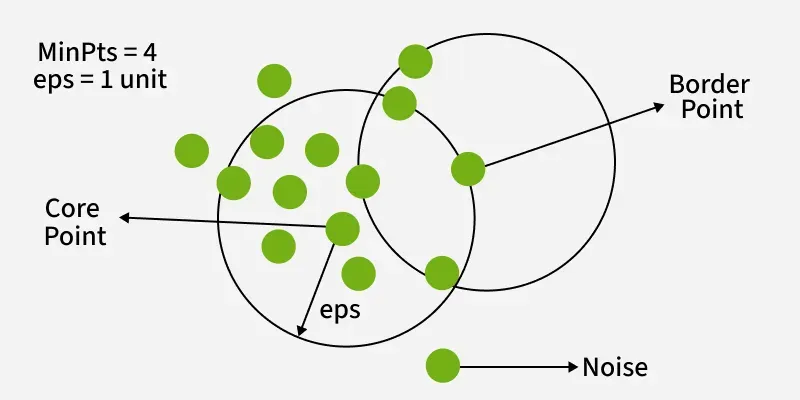

Here's a video explaining how the DBSCAN algorithm works: https://www.youtube.com/watch?v=C3r7tGRe2eI

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
model = DBSCAN(eps=1.1, min_samples=4)

In [ ]:
iris_df['species']

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [ ]:
model.fit(X)

DBSCAN(eps=1.1, min_samples=4)

##### In DBSCAN, there's no prediction step. It directly assigns labels to all the inputs.

In [ ]:
model.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

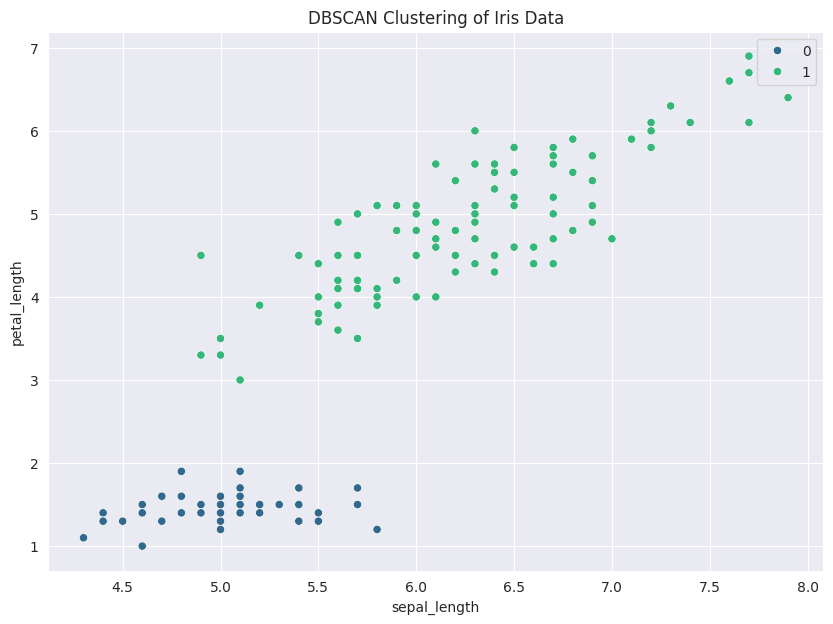

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 7))
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=model.labels_, palette='viridis', legend='full')

# Optional: Highlight noise points (-1 label) if any
noise_points = X[model.labels_ == -1]
if not noise_points.empty:
    sns.scatterplot(data=noise_points, x='sepal_length', y='petal_length', color='gray', marker='x', s=100, label='Noise')

plt.title('DBSCAN Clustering of Iris Data')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.show()

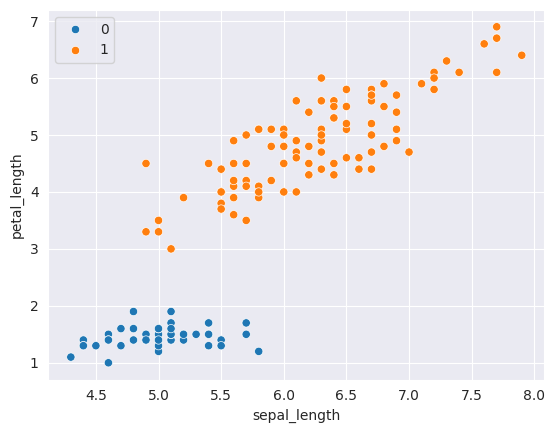

In [ ]:
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=model.labels_);

### Hierarchical Clustering

Hierarchical clustering, as the name suggests, creates a hierarchy or a tree of clusters.

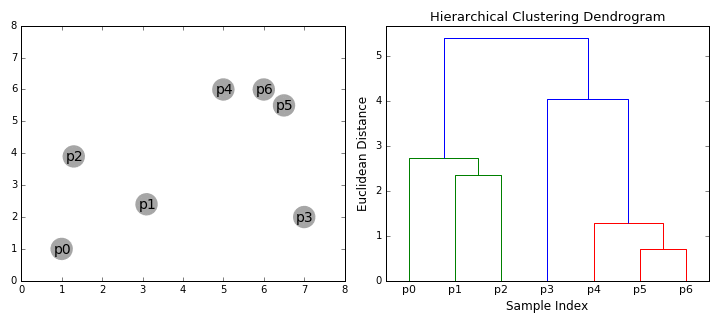

While there are several approaches to hierarchical clustering, the most common approach works as follows:

1. Mark each point in the dataset as a cluster.
2. Pick the two closest cluster centers without a parent and combine them into a new cluster.
3. The new cluster is the parent cluster of the two clusters, and its center is the mean of all the points in the cluster.
3. Repeat steps 2 and 3 till there's just one cluster left.

Watch this video for a visual explanation of hierarchical clustering: https://www.youtube.com/watch?v=7xHsRkOdVwo

### Principal Component Analysis (PCA)

Principal component is a dimensionality reduction technique that uses linear projections of data to reduce their dimensions, while attempting to maximize the variance of data in the projection. Watch this video to learn how PCA works: https://www.youtube.com/watch?v=FgakZw6K1QQ

Here's an example of PCA to reduce 2D data to 1D:

<img src="https://i.imgur.com/ZJ7utlo.png" width="480">

Here's an example of PCA to reduce 3D data to 2D:

<img src="https://lihan.me/assets/images/pca-illustration.png" width="640">


Let's apply Principal Component Analysis to the Iris dataset.

In [ ]:
iris_df = sns.load_dataset('iris')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

In [9]:
num_cols=numeric_cols

In [10]:
from sklearn.decomposition import PCA

In [45]:
pca = PCA(n_components=2)

In [46]:
pca_fit=pca.fit(iris_df[num_cols])

In [47]:
pca_fit.components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [48]:
transformed = pca.transform(iris_df[num_cols])

In [49]:
transformed

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

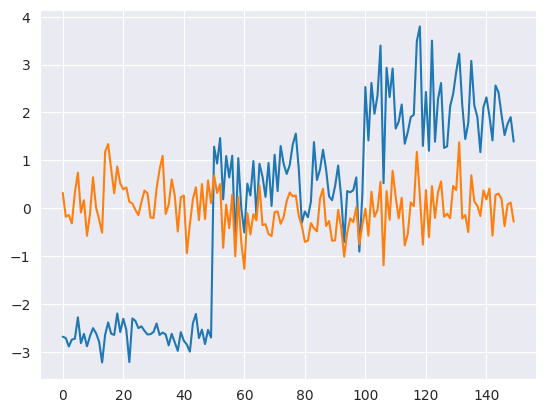

In [50]:
plt.plot(transformed)

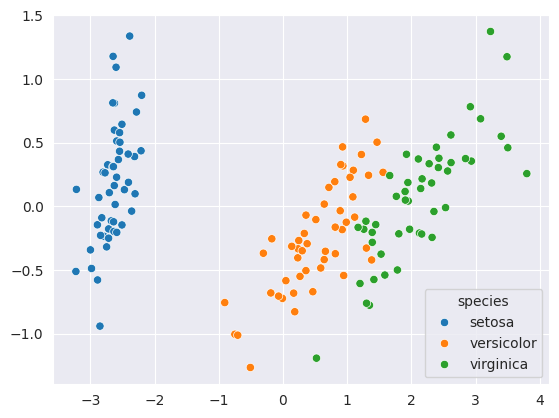

In [53]:
import numpy as np # Import numpy to use zeros_like
sns.scatterplot(x=transformed[:,0], y=transformed[:,1], hue=iris_df['species']);
# Note: `transformed[:,1]` attempts to access the second principal component.
# However, `pca` was initialized with `n_components=1`,
# meaning `transformed` only contains the first principal component at `transformed[:,0]`.
# Accessing `transformed[:,1]` would raise an IndexError.
# The `y` argument has been adjusted to `np.zeros_like(transformed[:,0])` to visualize the 1D PCA result.

### t-Distributed Stochastic Neighbor Embedding (t-SNE)

Manifold learning is an approach to non-linear dimensionality reduction. Algorithms for this task are based on the idea that the dimensionality of many data sets is only artificially high. Scikit-learn provides many algorithms for manifold learning: https://scikit-learn.org/stable/modules/manifold.html . A commonly-used manifold learning technique is t-Distributed Stochastic Neighbor Embedding or t-SNE, used to visualize high dimensional data in one, two or three dimensions.

Here's a visual representation of t-SNE applied to visualize 2 dimensional data in 1 dimension:

<img src="https://i.imgur.com/rVMAaix.png" width="360">


Here's a visual representation of t-SNE applied to the MNIST dataset, which contains 28px x 28px images of handrwritten digits 0 to 9, a reduction from 784 dimensions to 2 dimensions ([source](https://colah.github.io/posts/2014-10-Visualizing-MNIST/)):

<img src="https://indico.io/wp-content/uploads/2015/08/mnist-1024x607-1.jpg" width="640">

Here's a video explaning how t-SNE works: https://www.youtube.com/watch?v=NEaUSP4YerM

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(n_components=2)

In [ ]:
transformed = tsne.fit_transform(iris_df[numeric_cols])

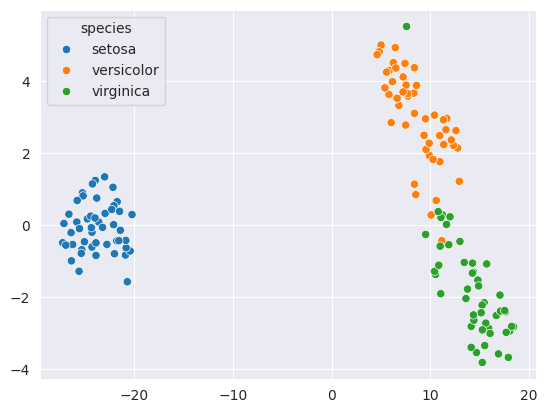

In [ ]:
sns.scatterplot(x=transformed[:,0], y=transformed[:,1], hue=iris_df['species']);